---
## 7. Análise de Satisfação do Cliente

> **Objetivo:** Entender como os clientes avaliam a experiência de compra — onde estão as notas baixas e o que as caracteriza.

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

df_orders_clean = pd.read_pickle("../df_orders_clean.pkl")
df_base = pd.read_csv("../base_analitica_final.csv")

COMPOSIÇÃO DO LEAD TIME MÉDIO DE ENTREGA
  1. Aprovação (compra → pgto aprovado):    0.4 dias  (3.2%)
  2. Postagem  (aprovado → transportadora):  2.8 dias  (22.5%)
  3. Trânsito  (transportadora → cliente):   9.2 dias  (74.2%)
  ─────────────────────────────────────────────────
  Total lead time médio:                   12.4 dias


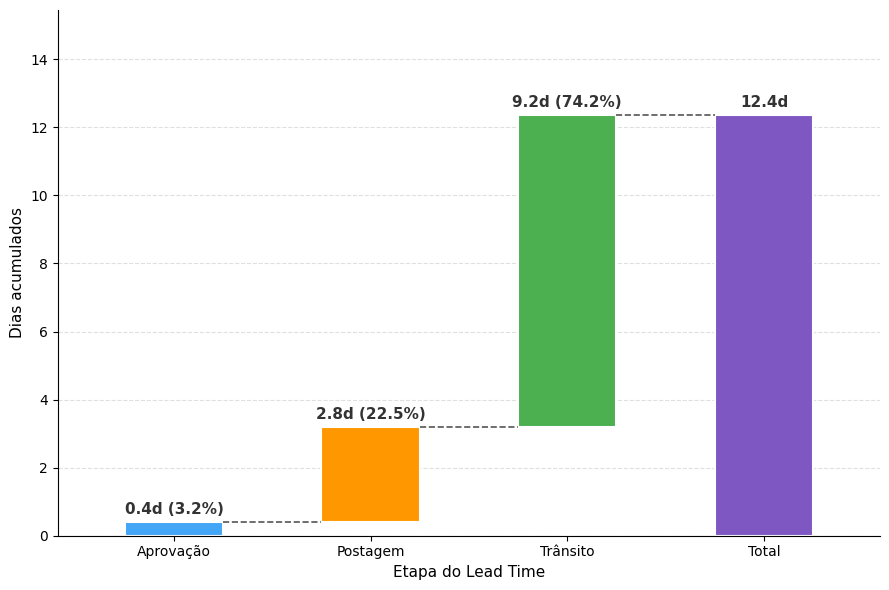


📊 Insight: A etapa de "Trânsito" é o maior gargalo, representando 74.2% do lead time total.


In [8]:
# ============================================================
# COMPOSIÇÃO DO LEAD TIME MÉDIO DE ENTREGA
# ============================================================
# O tempo total de entrega é dividido em 3 etapas:
#   1. Aprovação : compra → aprovação do pagamento
#   2. Postagem  : aprovação → entrega à transportadora
#   3. Trânsito  : transportadora → cliente
#
# Identificar qual etapa concentra o maior gargalo permite
# direcionar ações operacionais com maior precisão.
# ============================================================

# Calcula as 3 etapas do lead time (em dias)
df_lt = df_orders_clean.copy()
df_lt['etapa_aprovacao_dias'] = (
    df_lt['order_approved_at'] - df_lt['order_purchase_timestamp']
).dt.total_seconds() / 86400

df_lt['etapa_postagem_dias'] = (
    df_lt['order_delivered_carrier_date'] - df_lt['order_approved_at']
).dt.total_seconds() / 86400

df_lt['etapa_transito_dias'] = (
    df_lt['order_delivered_customer_date'] - df_lt['order_delivered_carrier_date']
).dt.total_seconds() / 86400

# Remove outliers das etapas (valores negativos ou absurdos)
df_lt = df_lt[
    (df_lt['etapa_aprovacao_dias'] >= 0) & (df_lt['etapa_aprovacao_dias'] <= 30) &
    (df_lt['etapa_postagem_dias']  >= 0) & (df_lt['etapa_postagem_dias']  <= 30) &
    (df_lt['etapa_transito_dias']  >= 0) & (df_lt['etapa_transito_dias']  <= 60)
]

# Médias das etapas
med_aprov  = df_lt['etapa_aprovacao_dias'].mean()
med_post   = df_lt['etapa_postagem_dias'].mean()
med_trans  = df_lt['etapa_transito_dias'].mean()
total_lt   = med_aprov + med_post + med_trans

print('=' * 55)
print('COMPOSIÇÃO DO LEAD TIME MÉDIO DE ENTREGA')
print('=' * 55)
print(f'  1. Aprovação (compra → pgto aprovado):  {med_aprov:>5.1f} dias  ({med_aprov/total_lt*100:.1f}%)')
print(f'  2. Postagem  (aprovado → transportadora):{med_post:>5.1f} dias  ({med_post/total_lt*100:.1f}%)')
print(f'  3. Trânsito  (transportadora → cliente): {med_trans:>5.1f} dias  ({med_trans/total_lt*100:.1f}%)')
print(f'  ─────────────────────────────────────────────────')
print(f'  Total lead time médio:                  {total_lt:>5.1f} dias')

# ---- GRÁFICO DE CASCATA (WATERFALL) ----
etapas  = ['Aprovação', 'Postagem', 'Trânsito', 'Total']
valores = [med_aprov, med_post, med_trans, total_lt]
cores   = ['#42A5F5', '#FF9800', '#4CAF50', '#7E57C2']

# Bases (offsets): cada etapa começa onde a anterior terminou
bases = [0, med_aprov, med_aprov + med_post, 0]

fig, ax = plt.subplots(figsize=(9, 6))

# Barra invisível (offset) — cria o efeito cascata
ax.bar(etapas, bases, color='none', edgecolor='none')

# Barras visíveis
bars = ax.bar(etapas, valores, bottom=bases, color=cores,
              edgecolor='white', linewidth=1.5, width=0.5)

# Linhas conectoras entre as etapas (efeito cascata)
acumulado = 0
for i, val in enumerate(valores[:-1]):
    x_inicio = i + 0.25
    x_fim    = i + 0.75
    y        = acumulado + val
    ax.plot([x_inicio, x_fim], [y, y], color='#555555', lw=1.2, ls='--')
    acumulado += val

# Rótulos acima de cada barra
for bar, base, val, etapa in zip(bars, bases, valores, etapas):
    pct = f' ({val/total_lt*100:.1f}%)' if etapa != 'Total' else ''
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        base + val + 0.15,
        f'{val:.1f}d{pct}',
        ha='center', va='bottom', fontsize=11, fontweight='bold', color='#333333'
    )

ax.axhline(0, color='#cccccc', lw=0.8)
ax.set_ylabel('Dias acumulados', fontsize=11)
ax.set_ylim(0, total_lt * 1.25)
ax.set_xlabel('Etapa do Lead Time', fontsize=11)
ax.spines[['top', 'right']].set_visible(False)
ax.yaxis.grid(True, linestyle='--', alpha=0.4)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

print(f'\n📊 Insight: A etapa de "{max(zip([med_aprov, med_post, med_trans], etapas[:3]), key=lambda x: x[0])[1]}" '
      f'é o maior gargalo, representando {max([med_aprov, med_post, med_trans])/total_lt*100:.1f}% do lead time total.')

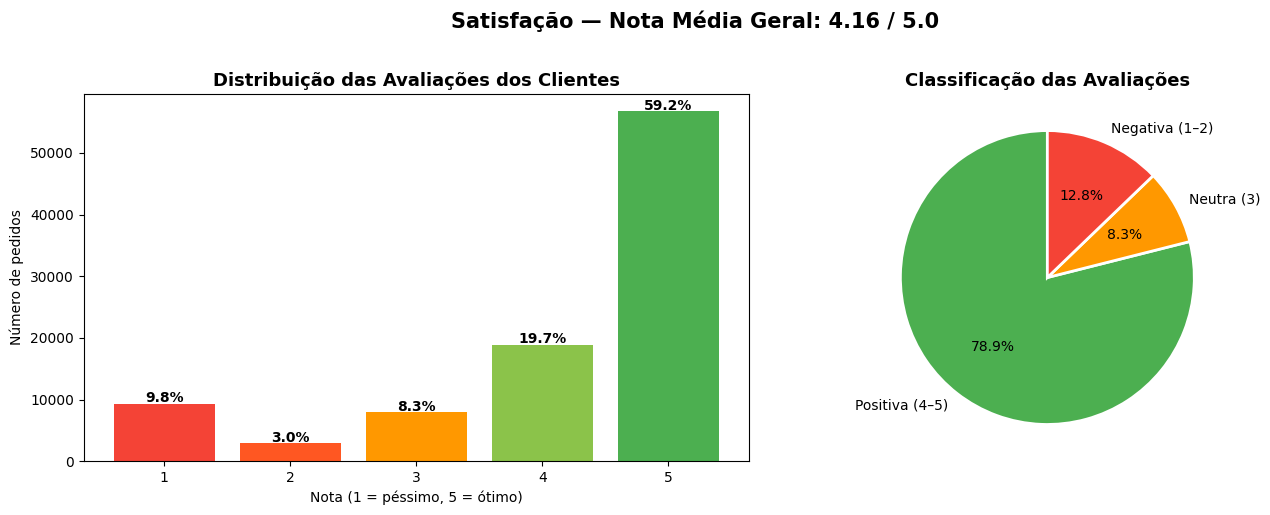


📊 12.8% dos clientes avaliaram com nota 1 ou 2 — avaliações críticas que impactam reputação.


In [9]:
# ============================================================
# GRÁFICO 4 — DISTRIBUIÇÃO DAS AVALIAÇÕES (REVIEW SCORE)
# ============================================================
# Por quê: o primeiro gráfico de satisfação precisa mostrar
# o panorama geral. A distribuição bimodal (muitos 1 e muitos 5)
# é uma característica típica de avaliações de e-commerce.
# ============================================================

df_rev = df_base.dropna(subset=['review_score'])
score_dist = df_rev['review_score'].value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribuição de notas (barras)
colors_score = ['#F44336','#FF5722','#FF9800','#8BC34A','#4CAF50']
bars = axes[0].bar(score_dist.index, score_dist.values, color=colors_score)
axes[0].set_title('Distribuição das Avaliações dos Clientes', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Nota (1 = péssimo, 5 = ótimo)')
axes[0].set_ylabel('Número de pedidos')
for bar, val in zip(bars, score_dist.values):
    pct = val / score_dist.sum() * 100
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
                 f'{pct:.1f}%', ha='center', fontsize=10, fontweight='bold')

# Pizza: positivo / neutro / negativo
class_dist = df_rev['classificacao_review'].value_counts()
class_order = ['Positiva (4–5)', 'Neutra (3)', 'Negativa (1–2)']
class_dist = class_dist.reindex(class_order, fill_value=0)
pie_colors = ['#4CAF50','#FF9800','#F44336']
axes[1].pie(
    class_dist.values,
    labels=class_dist.index,
    autopct='%1.1f%%',
    colors=pie_colors,
    startangle=90,
    wedgeprops={'edgecolor':'white','linewidth':2}
)
axes[1].set_title('Classificação das Avaliações', fontsize=13, fontweight='bold')

plt.suptitle(f'Satisfação — Nota Média Geral: {df_rev["review_score"].mean():.2f} / 5.0',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f'\n📊 {(df_rev["review_score"] <= 2).mean()*100:.1f}% dos clientes avaliaram com nota 1 ou 2 — avaliações críticas que impactam reputação.')

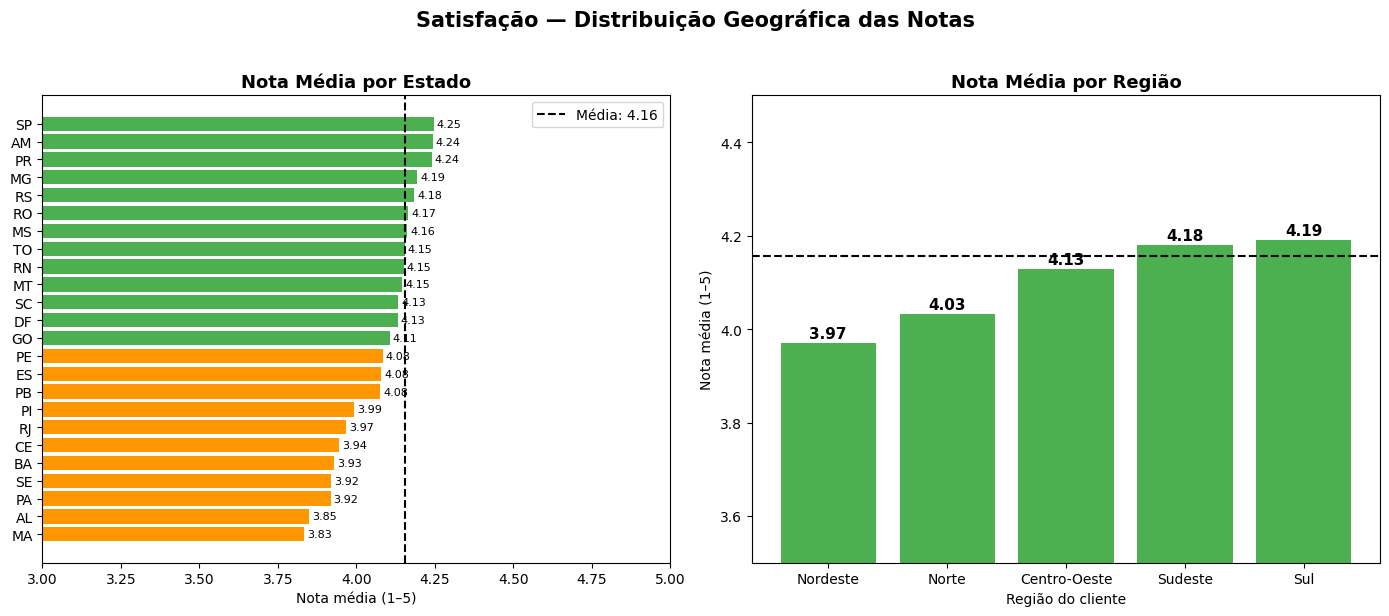


📊 Estados com nota média abaixo de 3.9:
customer_state  nota_media  total_reviews
            MA    3.832865            712
            AL    3.847716            394


In [10]:
# ============================================================
# GRÁFICO 5 — NOTA MÉDIA POR ESTADO E REGIÃO
# ============================================================
# Por quê: identifica onde os clientes estão menos satisfeitos
# geograficamente. Permite cruzar com os dados de SLA do bloco 7
# para confirmar se as regiões com pior entrega têm pior nota.
# Cores: vermelho < 3.8, laranja < 4.1, verde >= 4.1
# ============================================================

# Nota média por estado (estados com >= 100 avaliações)
estado_nota = (
    df_base.dropna(subset=['review_score'])
    .groupby('customer_state')
    .agg(
        nota_media    = ('review_score', 'mean'),
        total_reviews = ('review_score', 'count')
    )
    .reset_index()
)
estado_nota = estado_nota[estado_nota['total_reviews'] >= 100]
estado_nota_sorted = estado_nota.sort_values('nota_media')

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Nota por estado (barras horizontais)
colors_nota = ['#F44336' if x < 3.8 else '#FF9800' if x < 4.1 else '#4CAF50'
               for x in estado_nota_sorted['nota_media']]
bars = axes[0].barh(estado_nota_sorted['customer_state'], estado_nota_sorted['nota_media'],
                    color=colors_nota)
axes[0].axvline(df_base['review_score'].mean(), color='black', ls='--', lw=1.5,
                label=f'Média: {df_base["review_score"].mean():.2f}')
axes[0].set_xlim(3, 5)
axes[0].set_title('Nota Média por Estado', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Nota média (1–5)')
axes[0].legend()
for bar, val in zip(bars, estado_nota_sorted['nota_media']):
    axes[0].text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
                 f'{val:.2f}', va='center', fontsize=8)

# Nota por região
regiao_nota = (
    df_base.dropna(subset=['review_score'])
    .groupby('regiao_cliente')['review_score']
    .mean()
    .sort_values()
    .reset_index()
)
colors_reg = ['#F44336' if x < 3.9 else '#4CAF50' for x in regiao_nota['review_score']]
bars2 = axes[1].bar(regiao_nota['regiao_cliente'], regiao_nota['review_score'], color=colors_reg)
axes[1].set_ylim(3.5, 4.5)
axes[1].set_title('Nota Média por Região', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Nota média (1–5)')
axes[1].set_xlabel('Região do cliente')
axes[1].axhline(df_base['review_score'].mean(), color='black', ls='--', lw=1.5)
for bar, val in zip(bars2, regiao_nota['review_score']):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f'{val:.2f}', ha='center', fontsize=11, fontweight='bold')

plt.suptitle('Satisfação — Distribuição Geográfica das Notas', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Cruzamento: estados com pior nota vs pior SLA
print('\n📊 Estados com nota média abaixo de 3.9:')
pior_nota = estado_nota_sorted[estado_nota_sorted['nota_media'] < 3.9][['customer_state','nota_media','total_reviews']]
print(pior_nota.to_string(index=False))